In [1]:
%cd ../../../DATASETS/embeddings
%ls

/Users/alexdominguez/Documents/GitHub/TFM/DATASETS/embeddings
ESM_sequence_embeddings_with_accession.csv
GeOKG/
ProstT5_sequence_embeddings_with_accession.csv
ProtT5_sequence_embeddings_with_accession.csv
ProttT5/


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap

sns.set(style="whitegrid")

def load_embeddings_with_labels(embed_path, label_path, id_col="code"):
    df_embed = pd.read_csv(embed_path)
    df_labels = pd.read_csv(label_path)

    df = df_embed.merge(df_labels, how="inner", left_on=id_col, right_on="uniprot_id")

    # Fallback to catch either dim_0 or numbered columns like "0", "1", ...
    emb_cols = [col for col in df.columns if col.startswith("dim_") or col.isdigit()]
    if not emb_cols:
        raise ValueError(f"No embedding columns found in {embed_path}. Columns: {df.columns.tolist()}")

    df["embedding"] = df[emb_cols].apply(lambda row: row.values.astype(np.float32), axis=1)
    return df


def reduce_and_plot(method, dfs_dict, label_col="class", n_components=2, figsize=(15, 4), title=None):
    fig, axes = plt.subplots(1, len(dfs_dict), figsize=figsize)
    if title:
        fig.suptitle(title, fontsize=16)
        
    for ax, (name, df) in zip(axes, dfs_dict.items()):
        embeddings = np.vstack(df["embedding"].to_numpy())
        labels = df[label_col].values

        if method == "PCA":
            reducer = PCA(n_components=n_components)
        elif method == "UMAP":
            reducer = umap.UMAP(n_components=n_components, random_state=42)
        elif method == "KMeans2":
            reducer = KMeans(n_clusters=2, random_state=42)
            clusters = reducer.fit_predict(embeddings)
            ax.scatter(embeddings[:, 0], embeddings[:, 1], c=clusters, cmap="coolwarm", alpha=0.6)
            ax.set_title(f"{name} (KMeans)")
            continue
        else:
            raise ValueError("Unsupported method")

        reduced = reducer.fit_transform(embeddings)
        scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="coolwarm", alpha=0.6)
        ax.set_title(f"{name} ({method})")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [25]:
# Paths
label_path = "../raw_data/uniprot_ids_labeled.csv"
paths = {
    "ESM": "ESM_sequence_embeddings_with_accession.csv",
    "ProtT5": "ProtT5_sequence_embeddings_with_accession.csv",
    "ProstT5": "ProstT5_sequence_embeddings_with_accession.csv"
}

# Load all datasets
all_dfs = {name: load_embeddings_with_labels(path, label_path) for name, path in paths.items()}

# Inspect the data
for name, df in all_dfs.items():
    print(f"{name}: {len(df)} entries")
    if len(df) > 0:
        emb = df["embedding"].iloc[0]
        print(f"  First embedding type: {type(emb)}, shape: {emb.shape if isinstance(emb, np.ndarray) else 'Not array'}")
    else:
        print("  EMPTY!")


ESM: 1412 entries
  First embedding type: <class 'numpy.ndarray'>, shape: (320,)
ProtT5: 1412 entries
  First embedding type: <class 'numpy.ndarray'>, shape: (1024,)
ProstT5: 1412 entries
  First embedding type: <class 'numpy.ndarray'>, shape: (1024,)


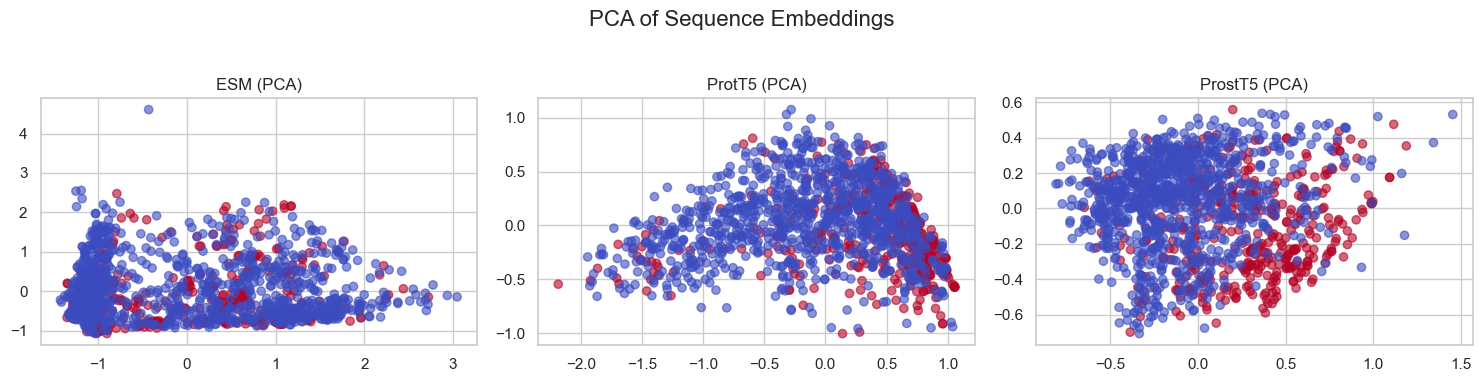

In [26]:
reduce_and_plot("PCA", all_dfs, title="PCA of Sequence Embeddings")

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

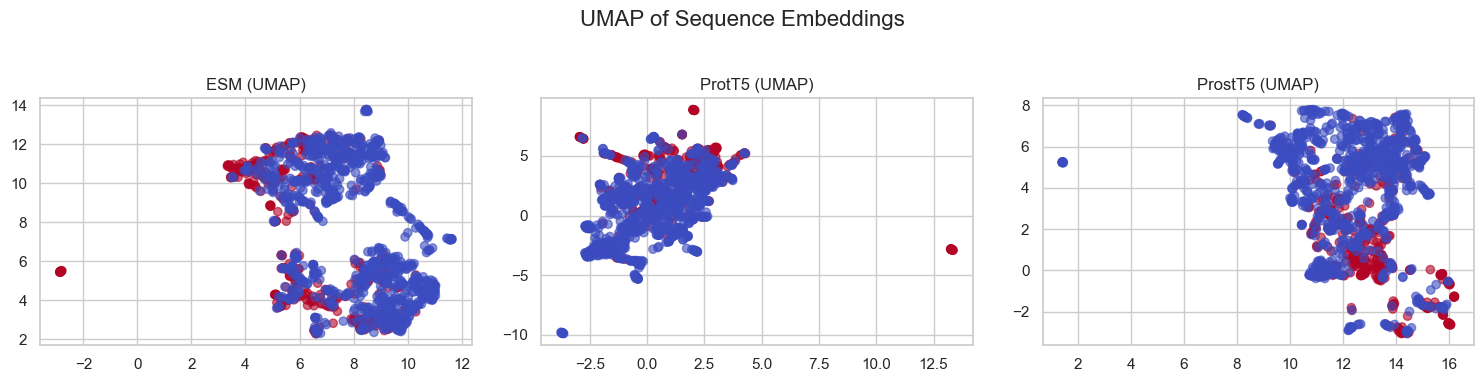

In [27]:
reduce_and_plot("UMAP", all_dfs, title="UMAP of Sequence Embeddings")

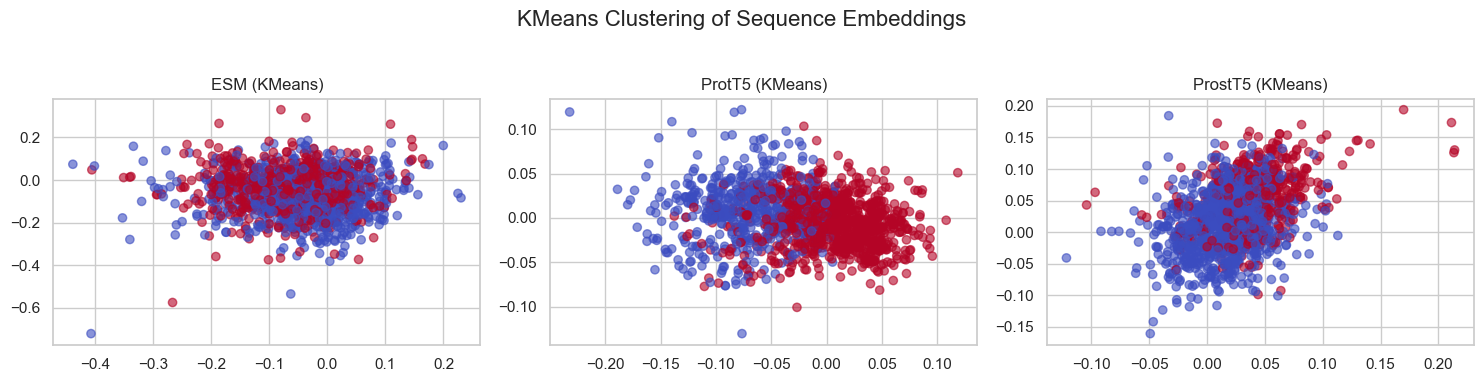

In [29]:
reduce_and_plot("KMeans2", all_dfs, title="KMeans Clustering of Sequence Embeddings")

GO Annotations

In [46]:
from glob import glob
import os
import re

geokg_folder = "../embeddings/GeOKG/2025-04-24"
label_path = "../raw_data/uniprot_ids_labeled.csv"

# Regex to extract dimension and category group
pattern = r"geokg_mean_embeddings_(\d+)dim_((?:C|F|C_F))_go_terms\.csv"

# Find all relevant files
files = glob(os.path.join(geokg_folder, "geokg_mean_embeddings_*_go_terms.csv"))

# Grouped dict: {dimension: {category: path}}
geokg_datasets = {}

for f in files:
    basename = os.path.basename(f)
    match = re.match(r"geokg_mean_embeddings_(\d+)dim_(C_F|C|F)_go_terms\.csv", basename)

    if match:
        dim, cat = match.groups()
        dim = int(dim)
        cat = cat.replace("CF", "C_F")  # unify naming
        if dim not in geokg_datasets:
            geokg_datasets[dim] = {}
        geokg_datasets[dim][cat] = f

In [47]:
all_dfs_by_dim = {}

for dim, category_paths in geokg_datasets.items():
    cat_dfs = {}
    for cat in ["C", "F", "C_F"]:
        if cat in category_paths:
            path = category_paths[cat]
            print(f"Loading: {path}")
            df = load_embeddings_with_labels(path, label_path, id_col="UniProt_ID")
            cat_dfs[cat] = df
    all_dfs_by_dim[dim] = cat_dfs

Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_500dim_C_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_500dim_F_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_500dim_C_F_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_200dim_C_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_200dim_F_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_200dim_C_F_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_100dim_C_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_100dim_F_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_100dim_C_F_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_1000dim_C_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_1000dim_F_go_terms.csv
Loading: ../embeddings/GeOKG/2025-04-24/geokg_mean_embeddings_1000di

In [50]:
def plot_geokg_by_dim(all_dfs_by_dim, method="PCA", dims=[50, 100, 200, 500, 1000]):
    """
    Plot PCA, UMAP, or KMeans2 for GeOKG embeddings by dimension in a fixed order.

    Parameters:
        all_dfs_by_dim (dict): Dictionary {dimension: {category: DataFrame}}
        method (str): One of "PCA", "UMAP", "KMeans2"
        dims (list): Order of dimensions to display
    """
    for dim in dims:
        if dim in all_dfs_by_dim:
            print(f"\n🔍 {method} for {dim}-dim GeOKG embeddings")
            reduce_and_plot(method, all_dfs_by_dim[dim], title=f"{method} - GeOKG {dim}D (C vs F vs C_F)")


🔍 PCA for 50-dim GeOKG embeddings


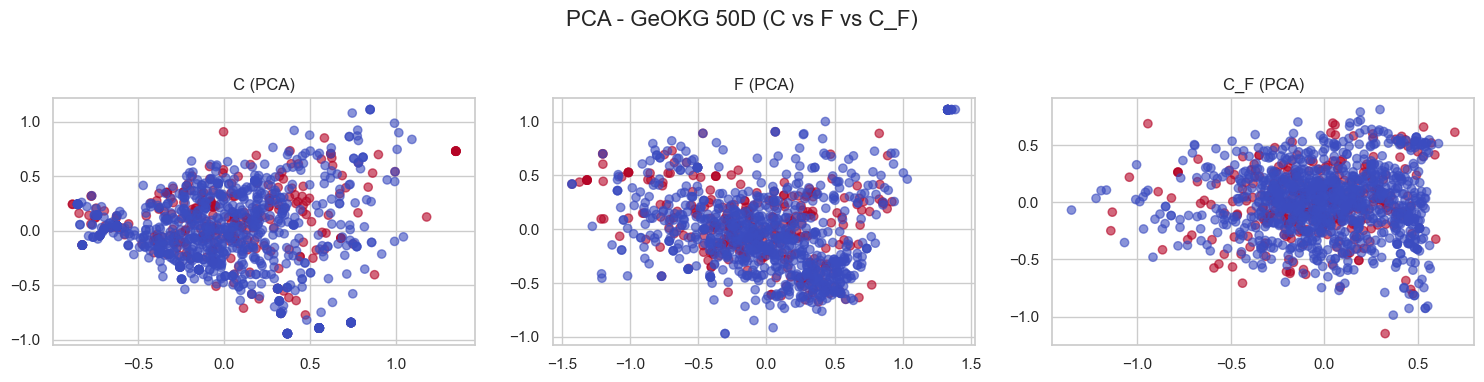


🔍 PCA for 100-dim GeOKG embeddings


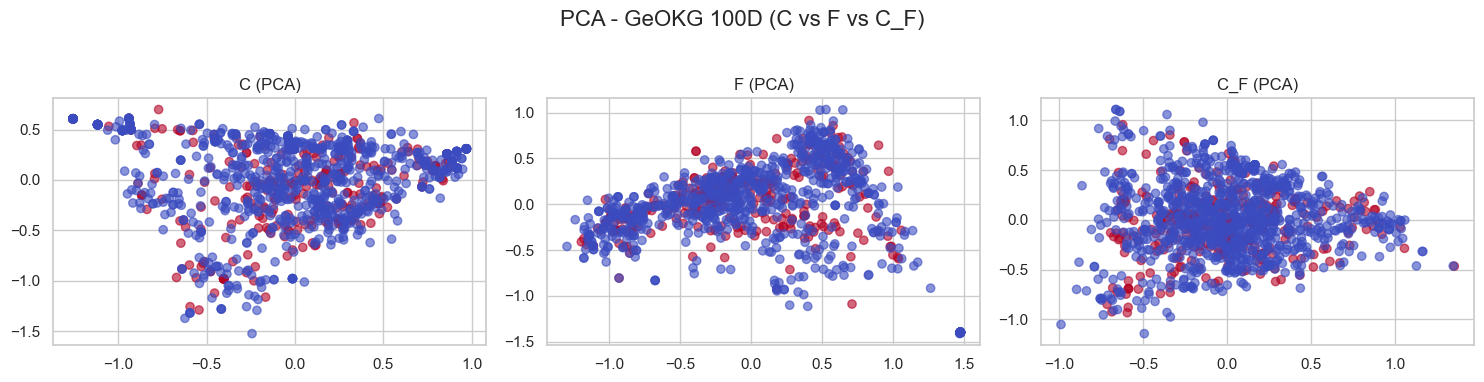


🔍 PCA for 200-dim GeOKG embeddings


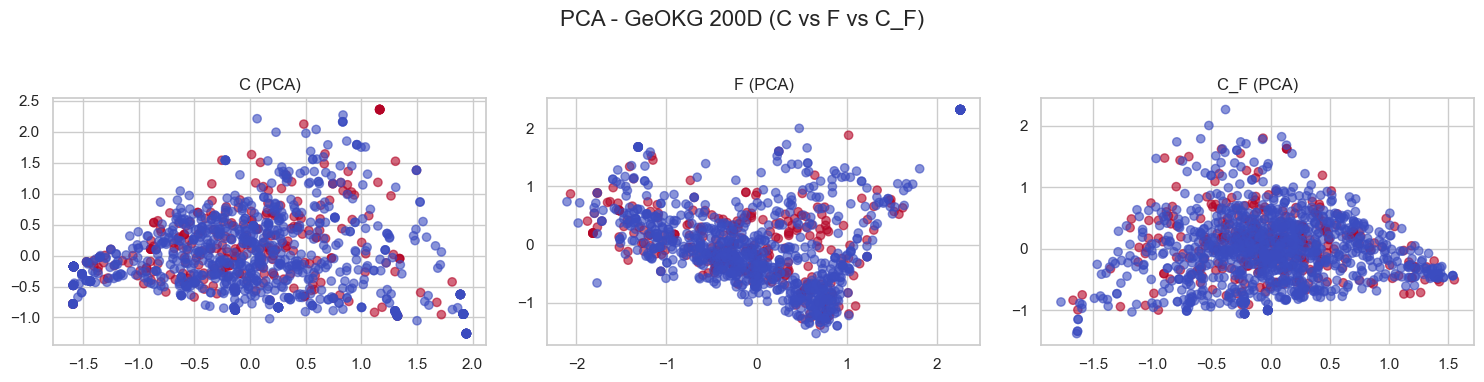


🔍 PCA for 500-dim GeOKG embeddings


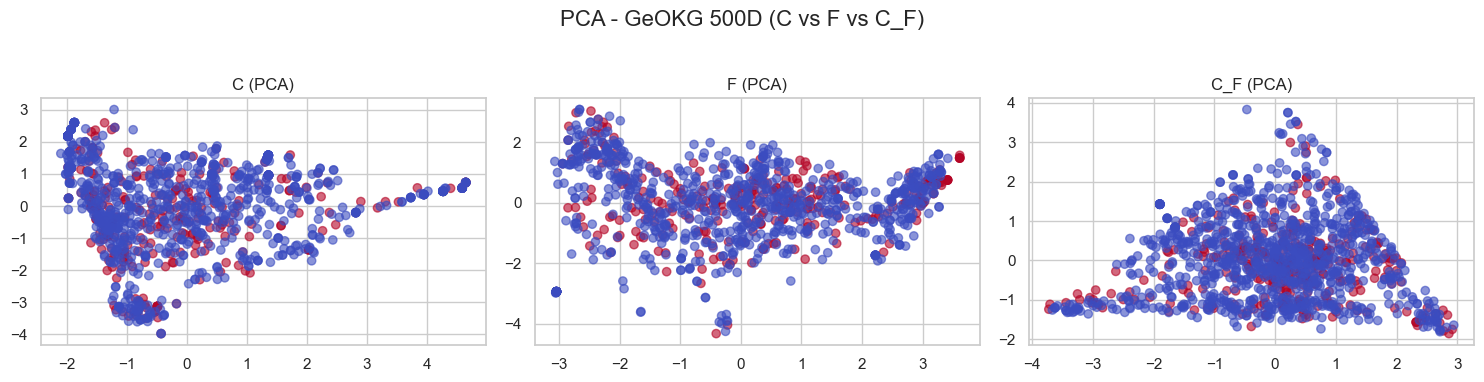


🔍 PCA for 1000-dim GeOKG embeddings


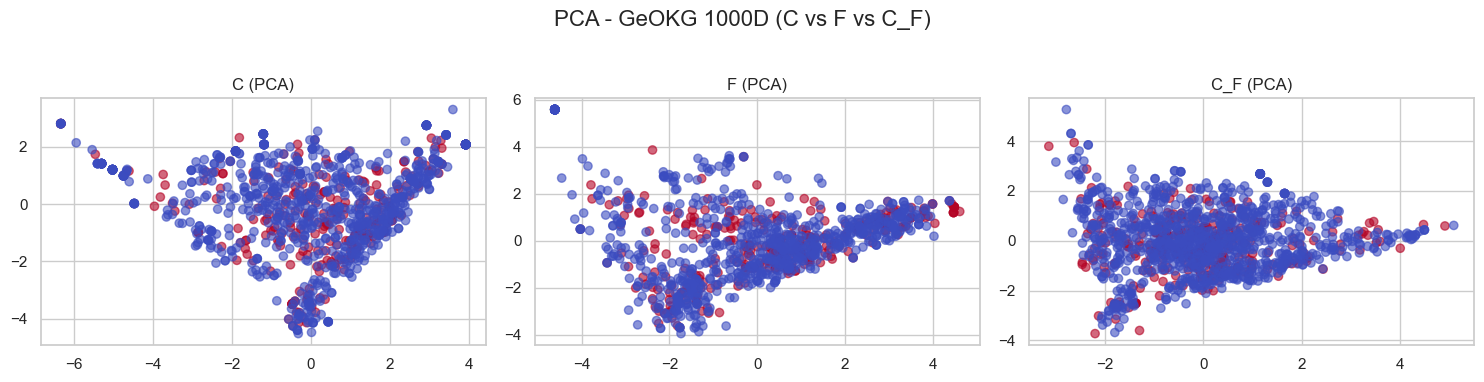

In [53]:
plot_geokg_by_dim(all_dfs_by_dim, method="PCA")


🔍 UMAP for 50-dim GeOKG embeddings


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

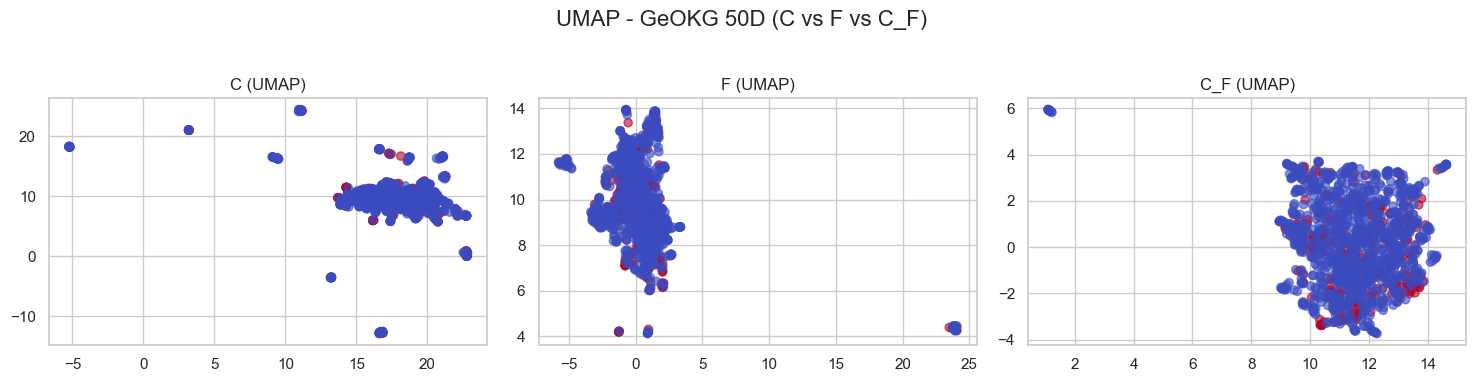


🔍 UMAP for 100-dim GeOKG embeddings


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

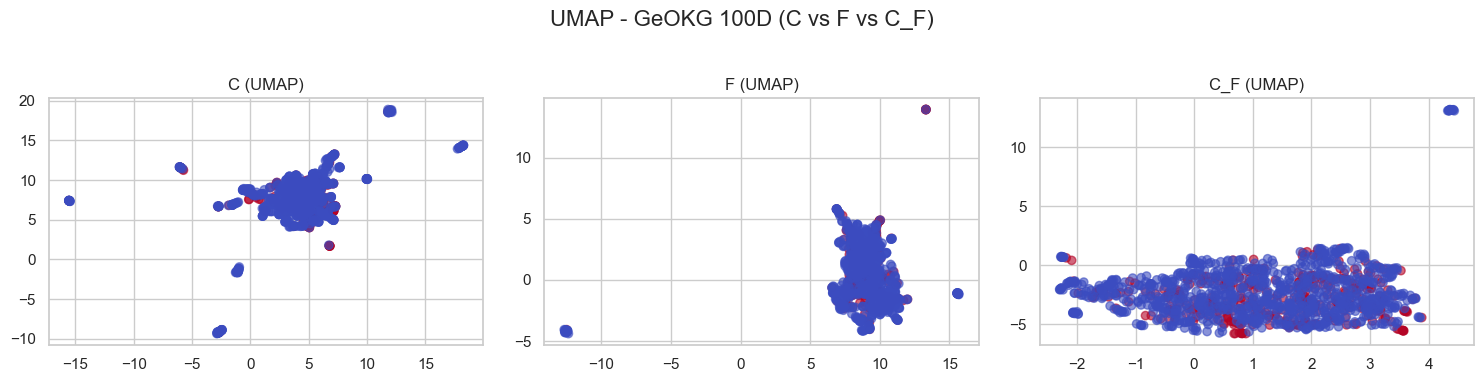


🔍 UMAP for 200-dim GeOKG embeddings


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

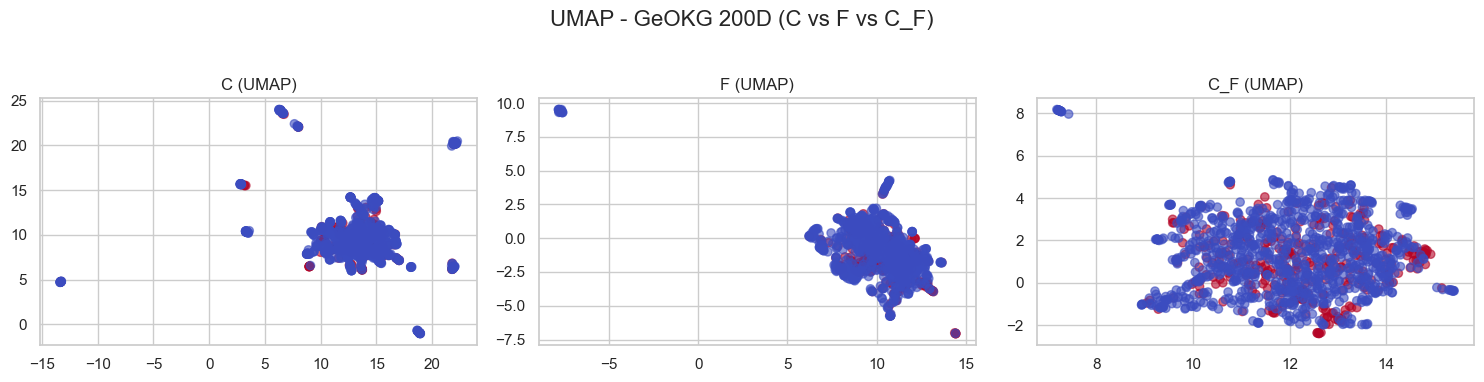


🔍 UMAP for 500-dim GeOKG embeddings


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

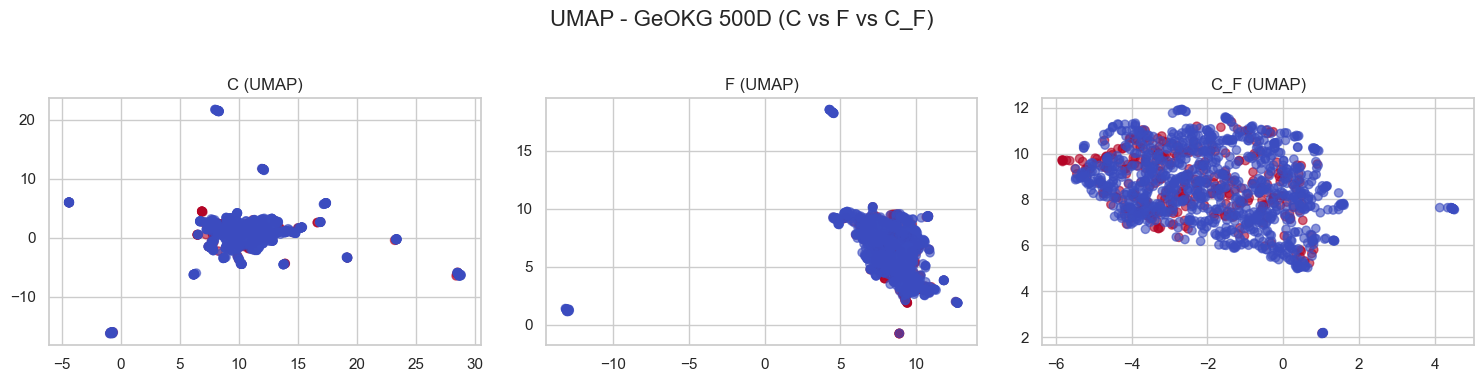


🔍 UMAP for 1000-dim GeOKG embeddings


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spe

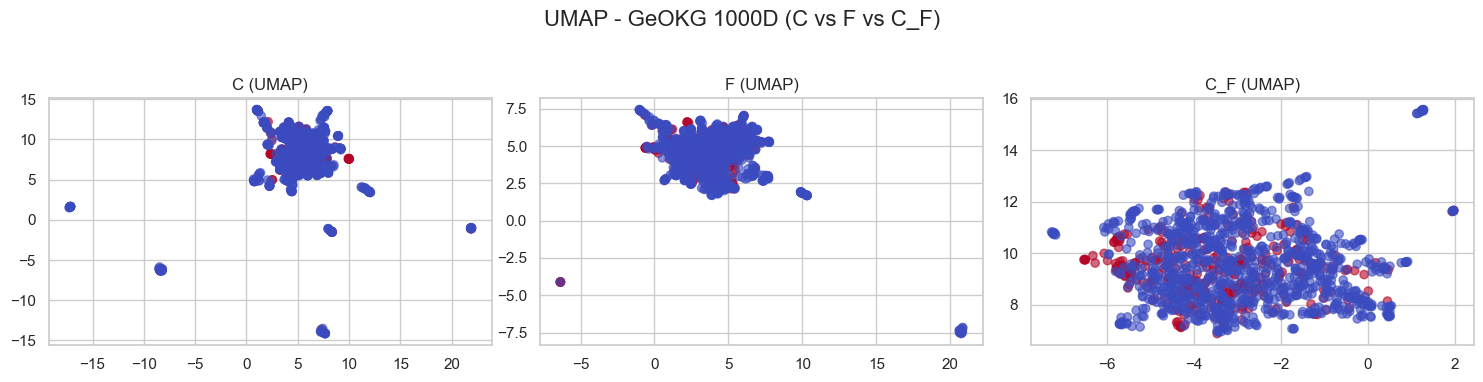

In [51]:
plot_geokg_by_dim(all_dfs_by_dim, method="UMAP")


🔍 KMeans2 for 50-dim GeOKG embeddings


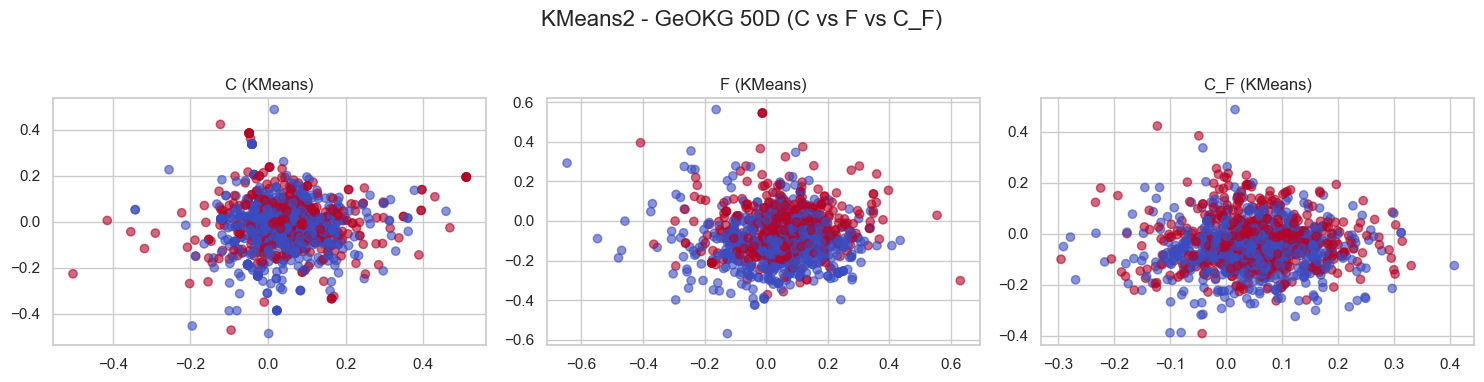


🔍 KMeans2 for 100-dim GeOKG embeddings


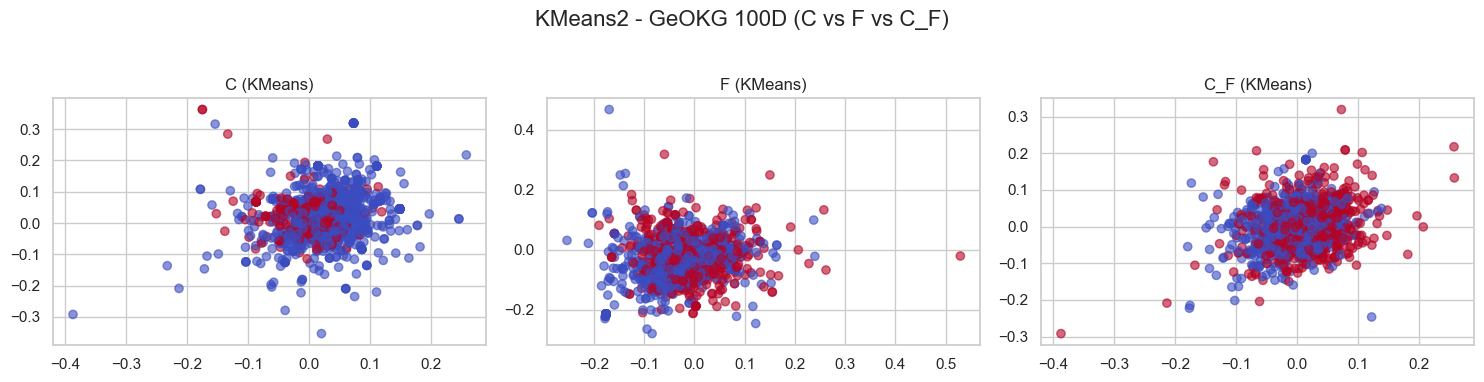


🔍 KMeans2 for 200-dim GeOKG embeddings


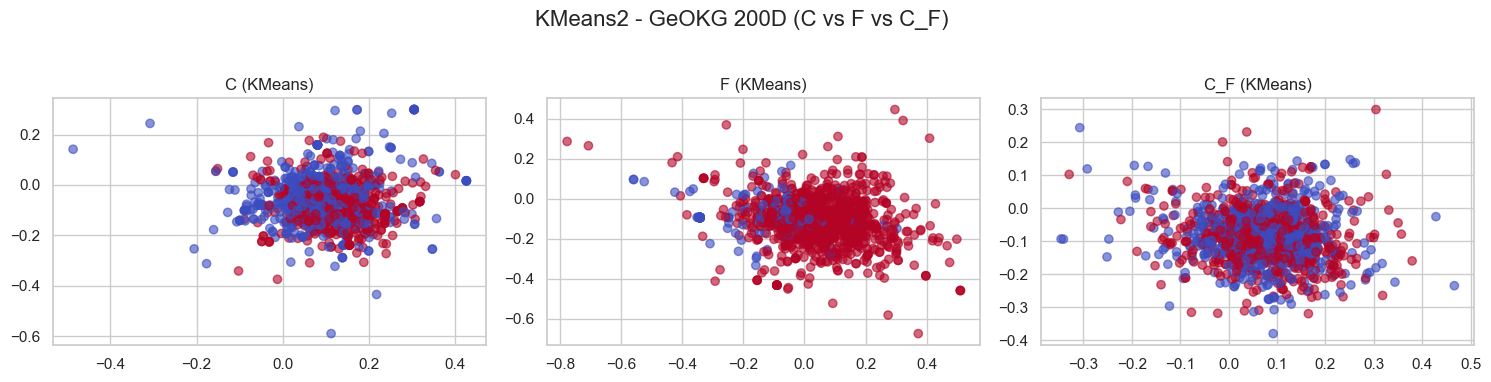


🔍 KMeans2 for 500-dim GeOKG embeddings


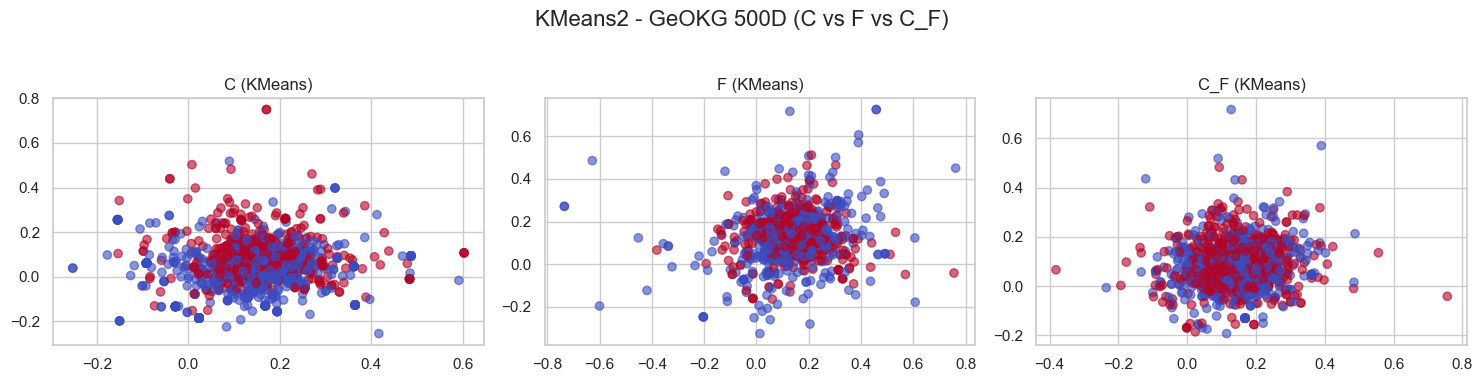


🔍 KMeans2 for 1000-dim GeOKG embeddings


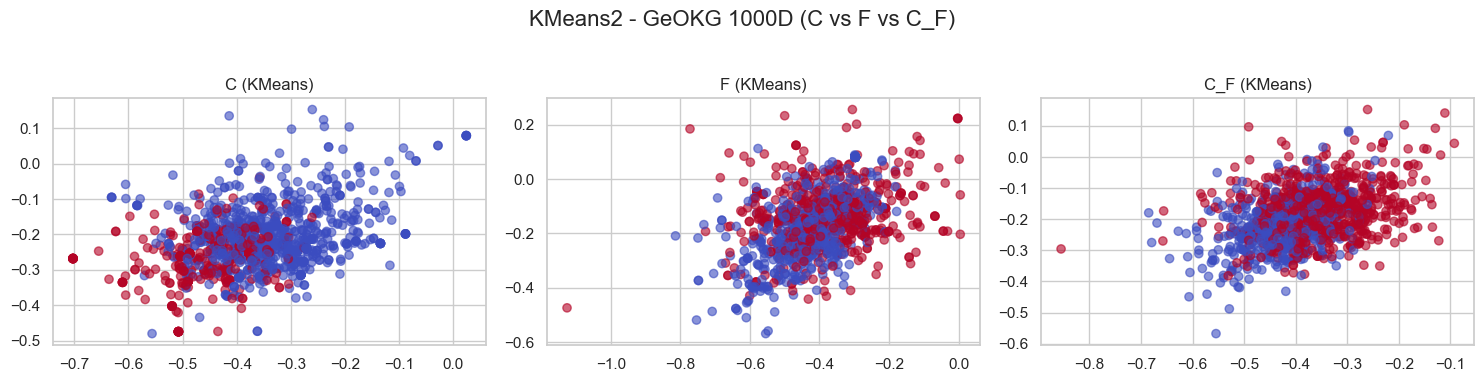

In [52]:
plot_geokg_by_dim(all_dfs_by_dim, method="KMeans2")